# XAI test 1



In [1]:

from XAI_test_1 import *


## simple linear combination test

### make example data 1

In [2]:

# 1. Setup & Data
X, y, feature_names = generate_synthetic_data(
        num_inputs=10, 
        num_samples=5000, 
        num_contributing_features=(2, 5), 
        weight_range=(-3, 3),
        noise_std=0.05,
    )

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info ---
Number of contributing variables (M): 2
Feature_9: weight = -2.9746
Feature_8: weight = -2.8430
-----------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_9   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 2.188e+05
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:35:41   Log-Likelihood:                 6269.0
No. Observations:                4000   AIC:                        -1.252e+04
Df Residuals:                    3989   BIC:                        -1.245e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

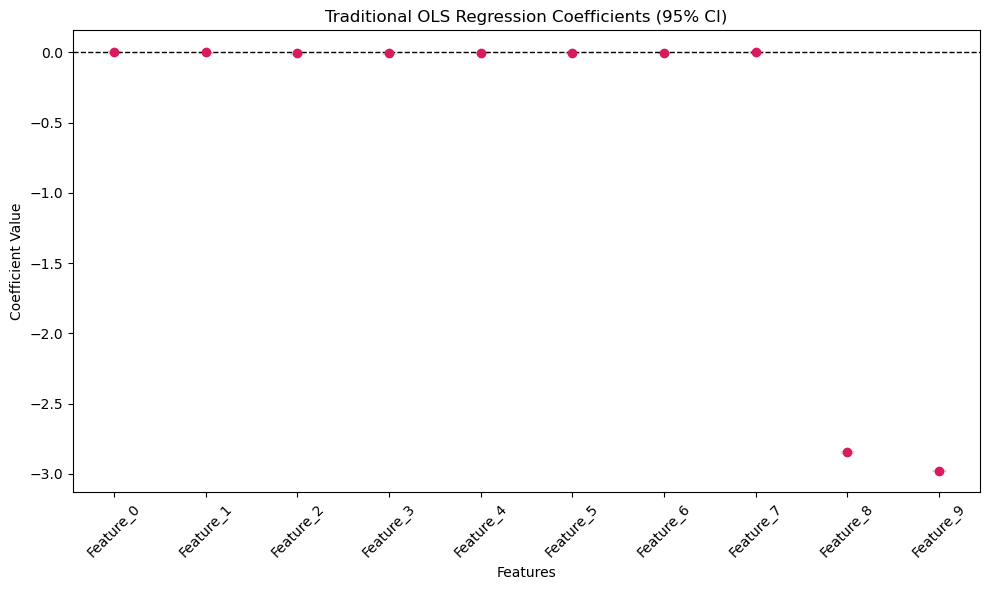


Statistically Significant Features (p < 0.05):
['Feature_8', 'Feature_9']


In [3]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [4]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### look at XGBoost Native Importances

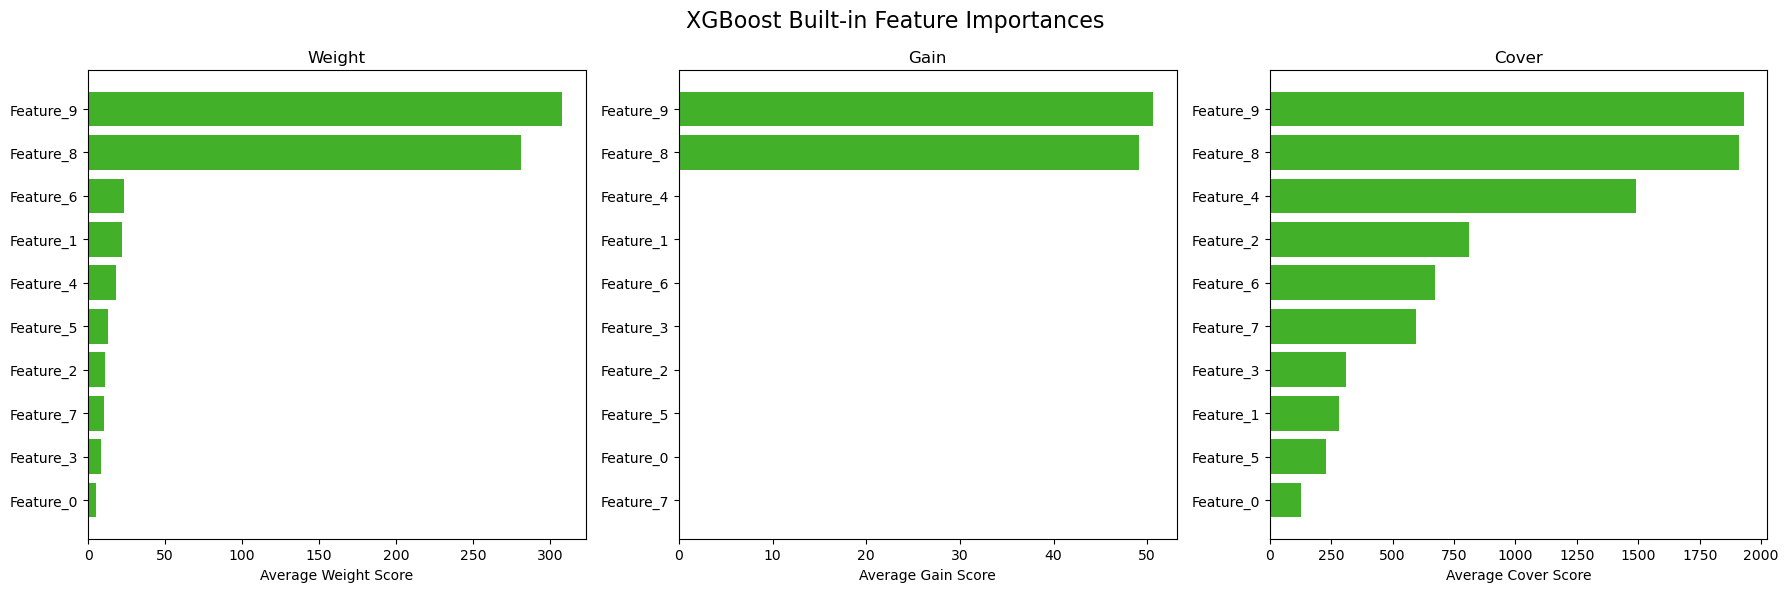

In [5]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [6]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


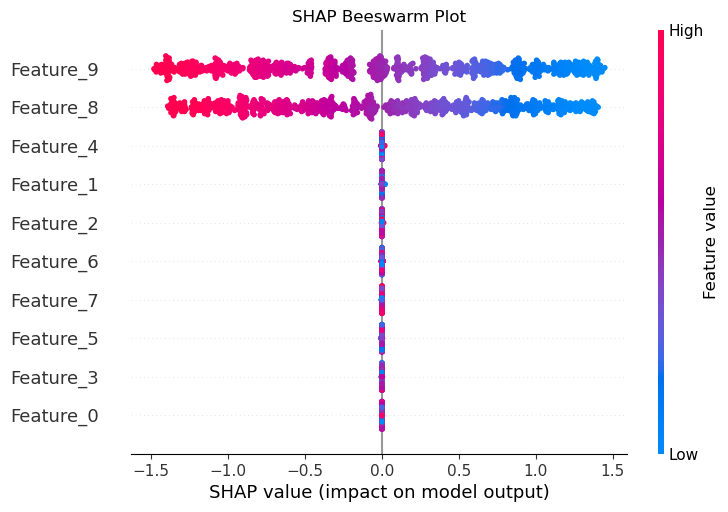

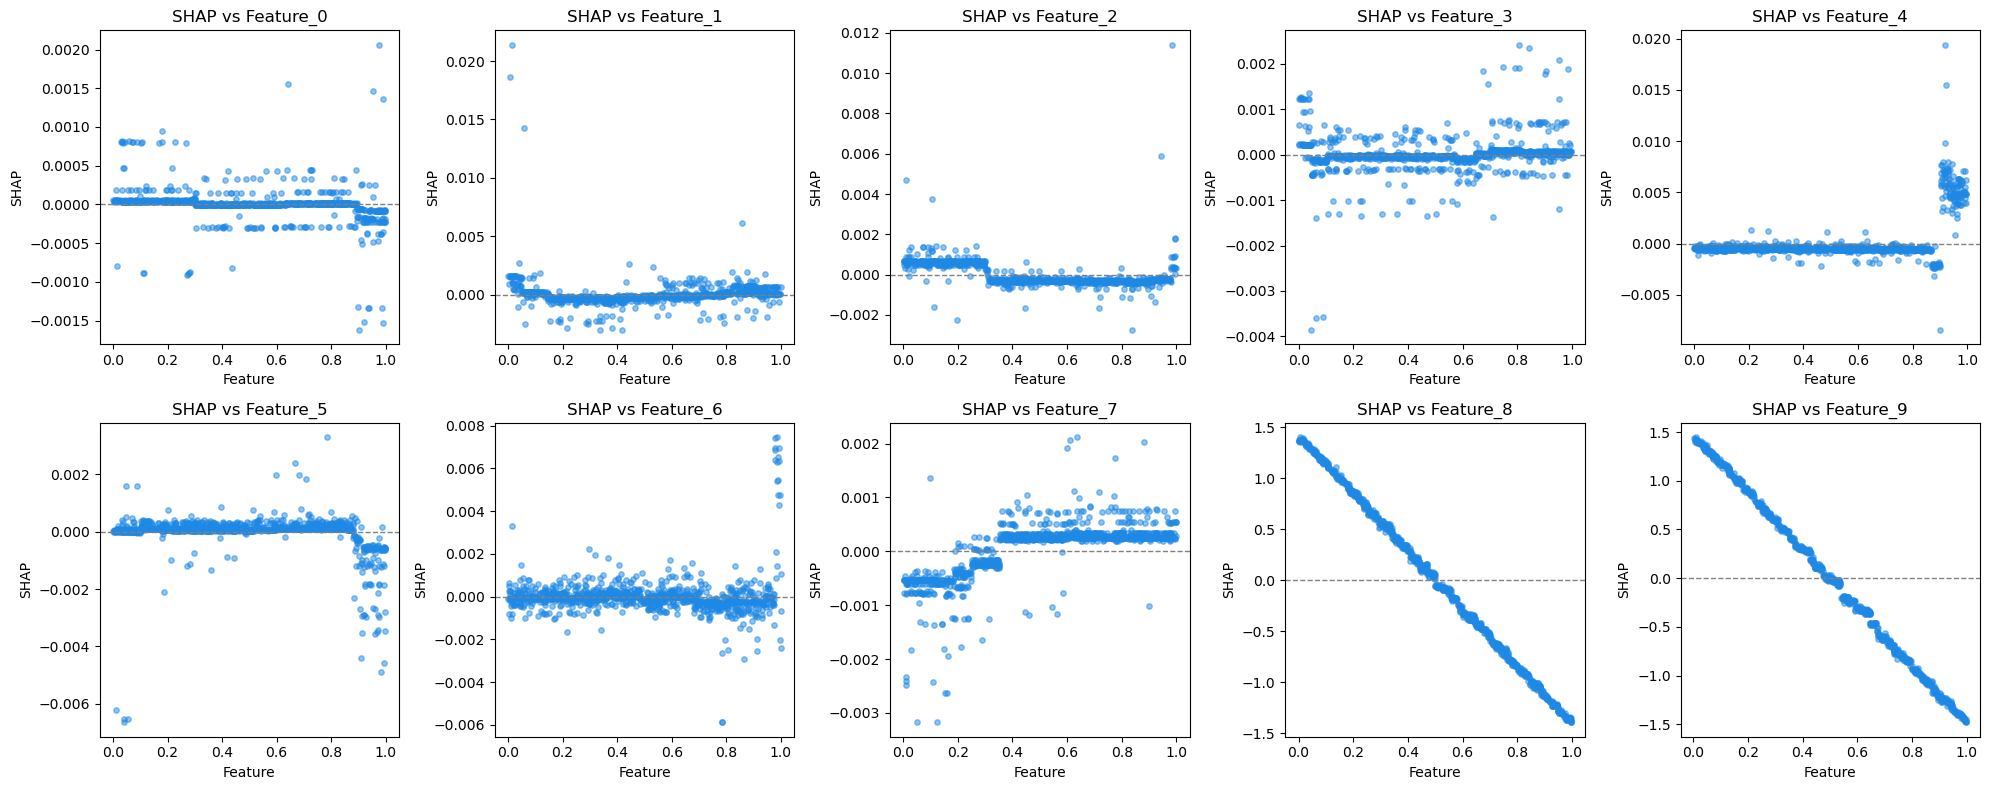

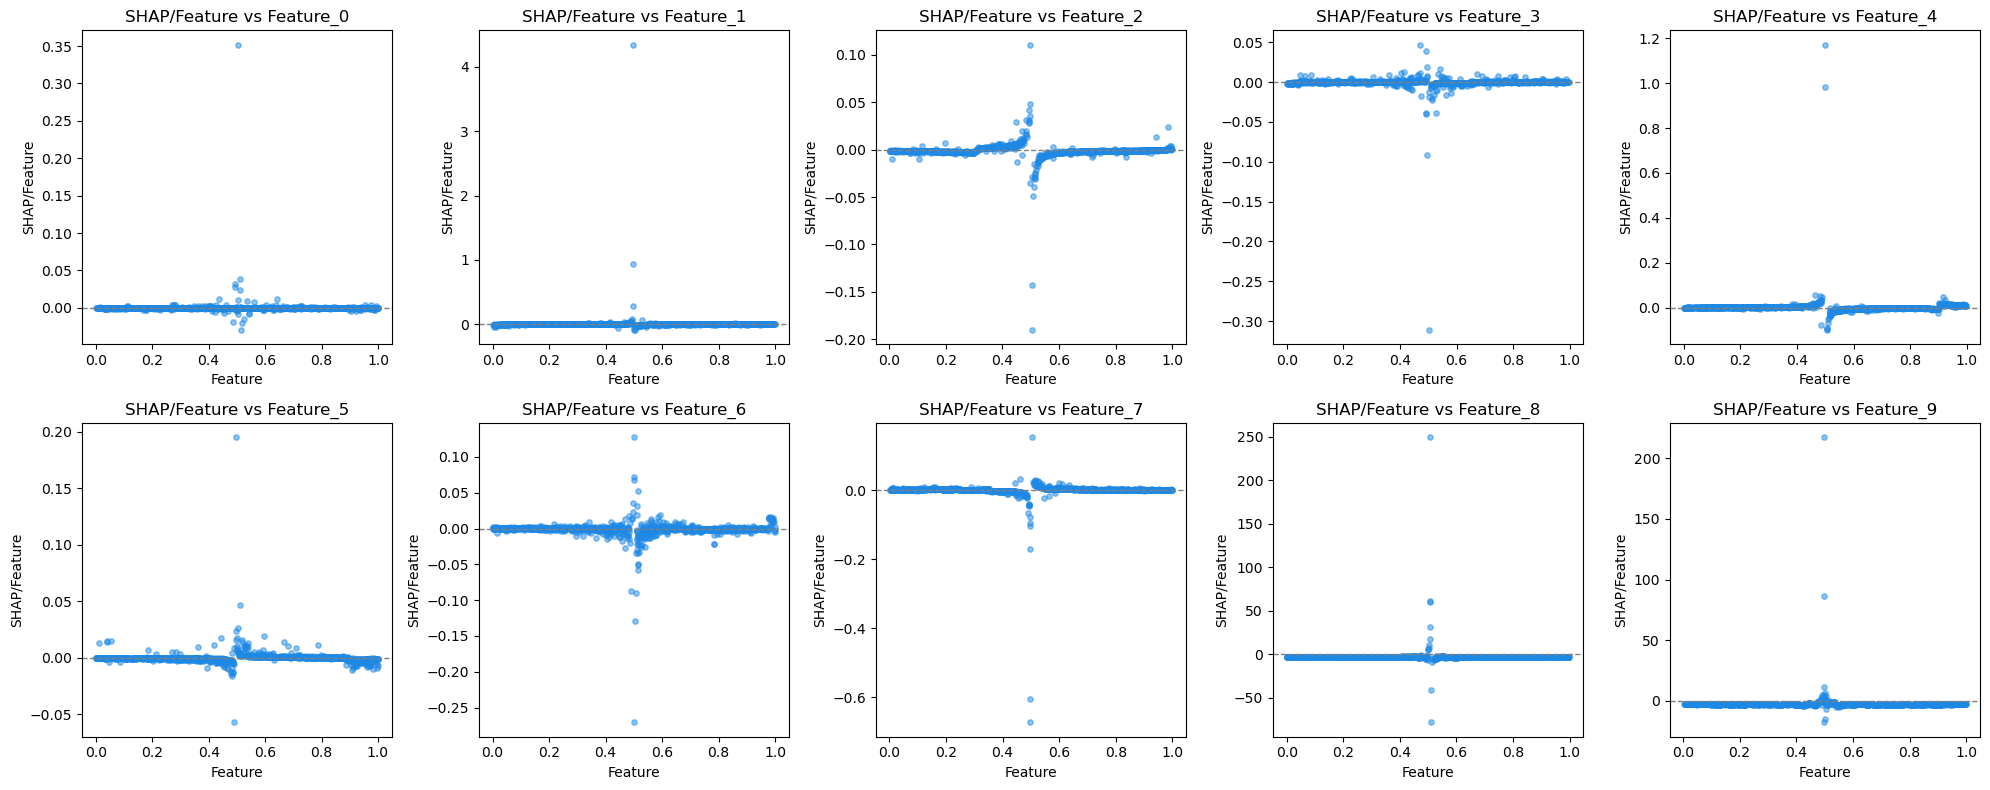

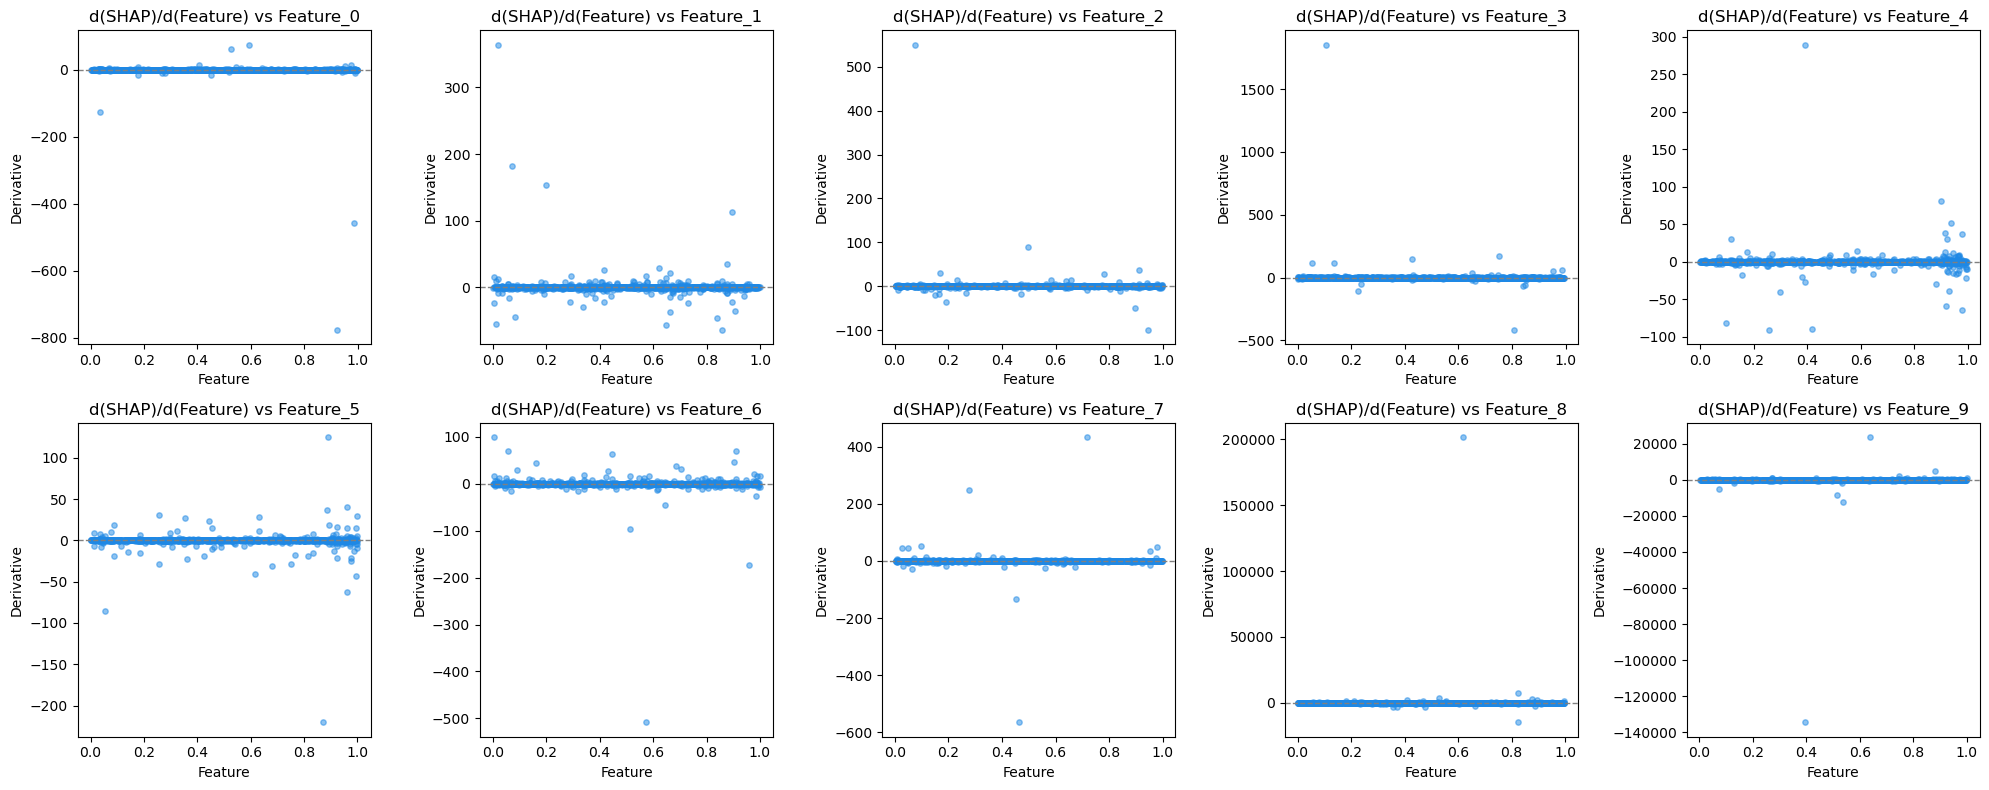

In [7]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we shouldn't see any


--- Computing SHAP Interaction Values ---


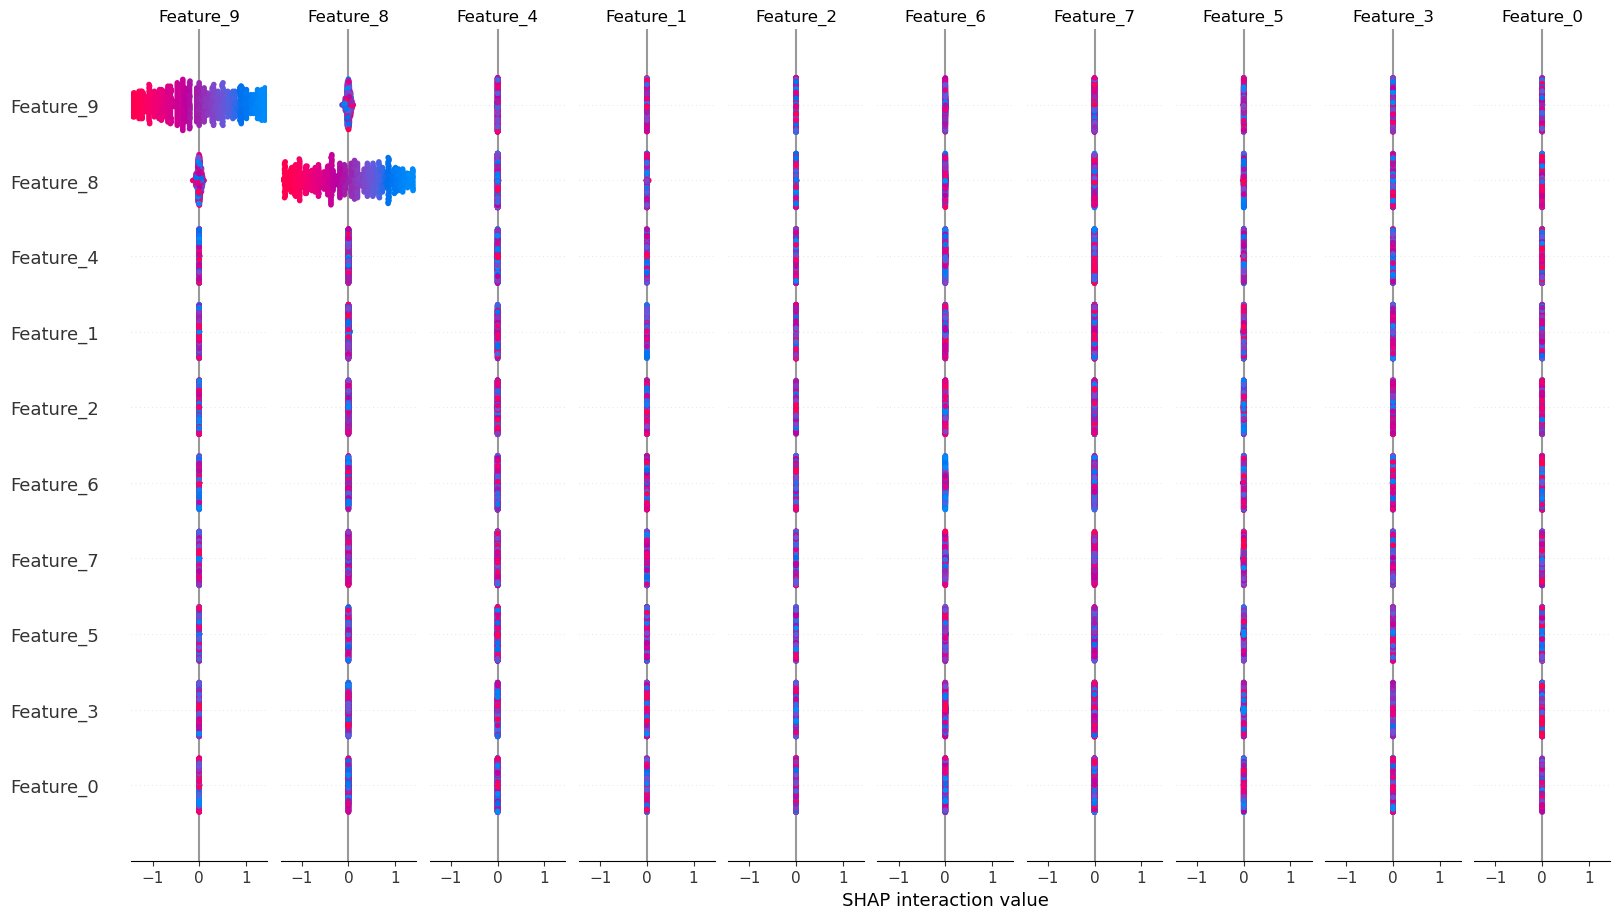


Strongest Interaction found by SHAP: Feature_9 & Feature_8
Plotting pure interaction effect for Feature_9 and Feature_8...


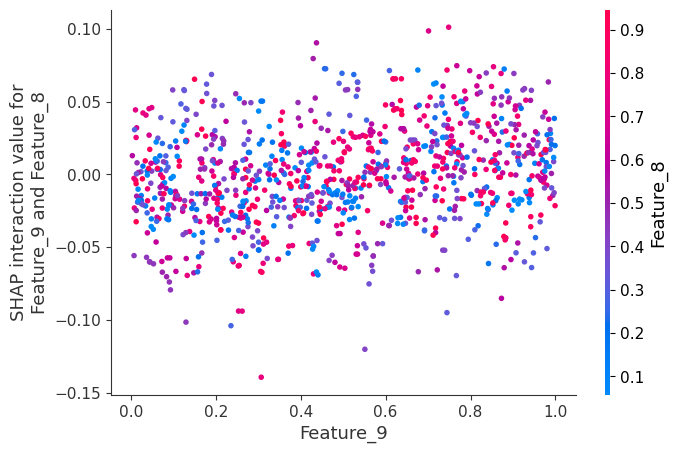

In [8]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [9]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_9: 0.7437
  Feature_8: 0.7004
  Feature_4: 0.0012
  Feature_1: 0.0005
  Feature_2: 0.0005
  Feature_6: 0.0004
  Feature_7: 0.0004
  Feature_5: 0.0003
  Feature_3: 0.0002
  Feature_0: 0.0001

Ranked Features (Most to Least Important):
['Feature_9', 'Feature_8', 'Feature_4', 'Feature_1', 'Feature_2', 'Feature_6', 'Feature_7', 'Feature_5', 'Feature_3', 'Feature_0']


## test for linear combination with some feature interactions

### make example data 2

In [10]:

# 1. Setup & Data
X, y, feature_names = generate_synthetic_data_with_interactions(
    num_inputs=10, 
    num_samples=5000, 
    num_contributing_features=(2, 5), 
    weight_range=(-3, 3),
    num_interactions=(1, 2),
    interaction_weight_range=(-3, 3),
    noise_std=0.05,
)

# Split data here so both OLS and XGBoost train on the exact same subsets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


--- Generative Model Info (With Interactions) ---
Number of linear variables (M): 2
  Feature_7: weight = -2.2165
  Feature_5: weight = -0.6691

Number of interaction terms: 2
  Feature_2 * Feature_4: weight = 0.8859
  Feature_5 * Feature_6: weight = -0.1958
-------------------------------------------------



### make the Traditional Baseline (OLS)


--- Traditional Regression Analysis (OLS) ---
                            OLS Regression Results                            
Dep. Variable:              Feature_5   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 2.227e+04
Date:                Sun, 15 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:35:48   Log-Likelihood:                 3857.3
No. Observations:                4000   AIC:                            -7693.
Df Residuals:                    3989   BIC:                            -7623.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const

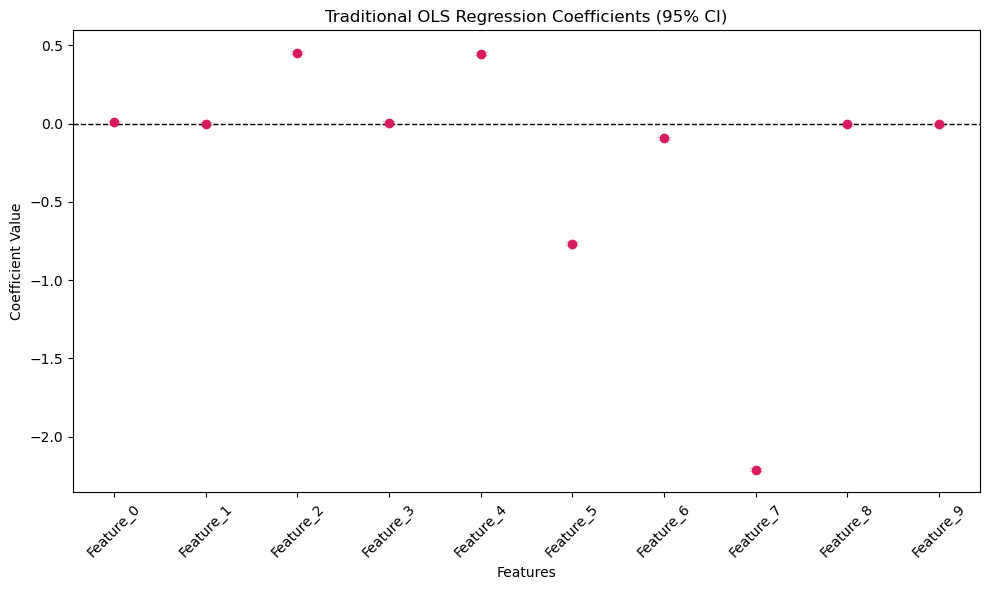


Statistically Significant Features (p < 0.05):
['Feature_2', 'Feature_4', 'Feature_5', 'Feature_6', 'Feature_7']


In [11]:

# 2. Traditional Baseline (OLS)
perform_traditional_regression(X_train, y_train)


### make a simple xgboost model for test 1

In [12]:

# 3. Machine Learning Modeling (XGBoost)
# We pass the pre-split data directly to ensure apples-to-apples comparison
model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

### look at XGBoost Native Importances

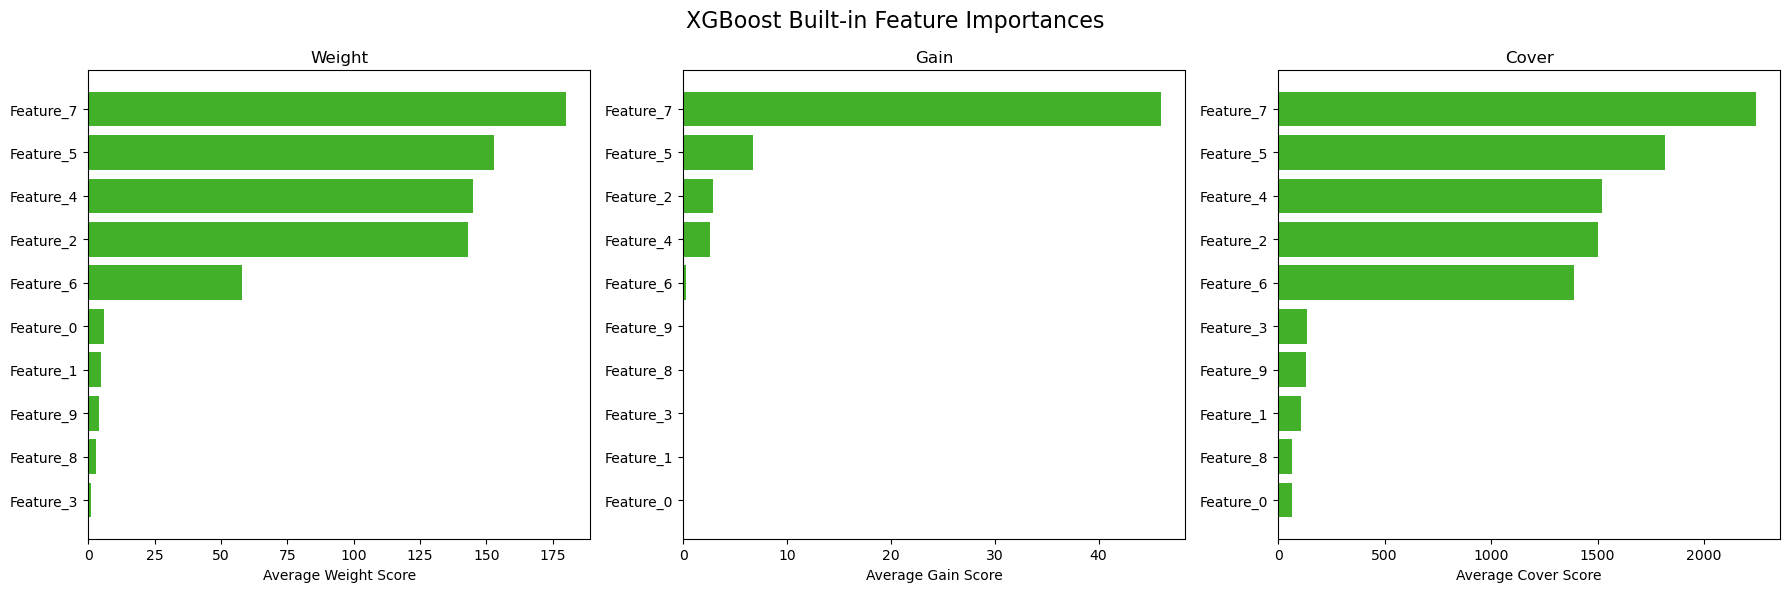

In [13]:

# 4. XGBoost Native Importances
plot_all_xgb_importances(model, feature_names)


### try to use SHAP to find the influencing inputs

In [14]:

# 5. Explainability (SHAP)
shap_values = compute_shap_values(model, X_train, X_test)


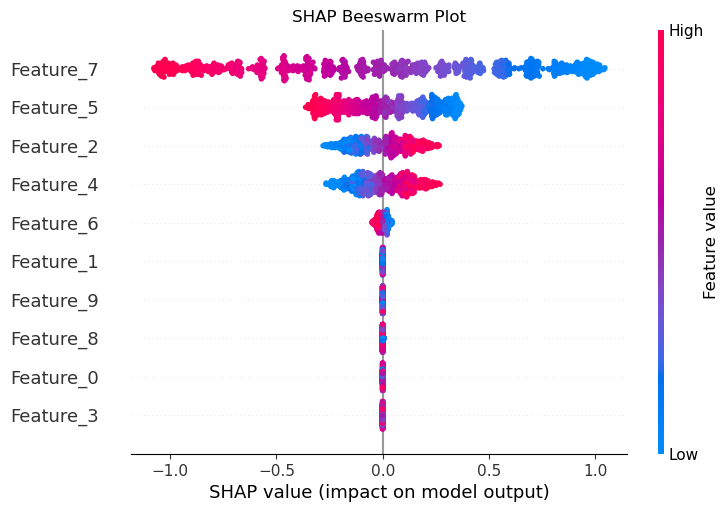

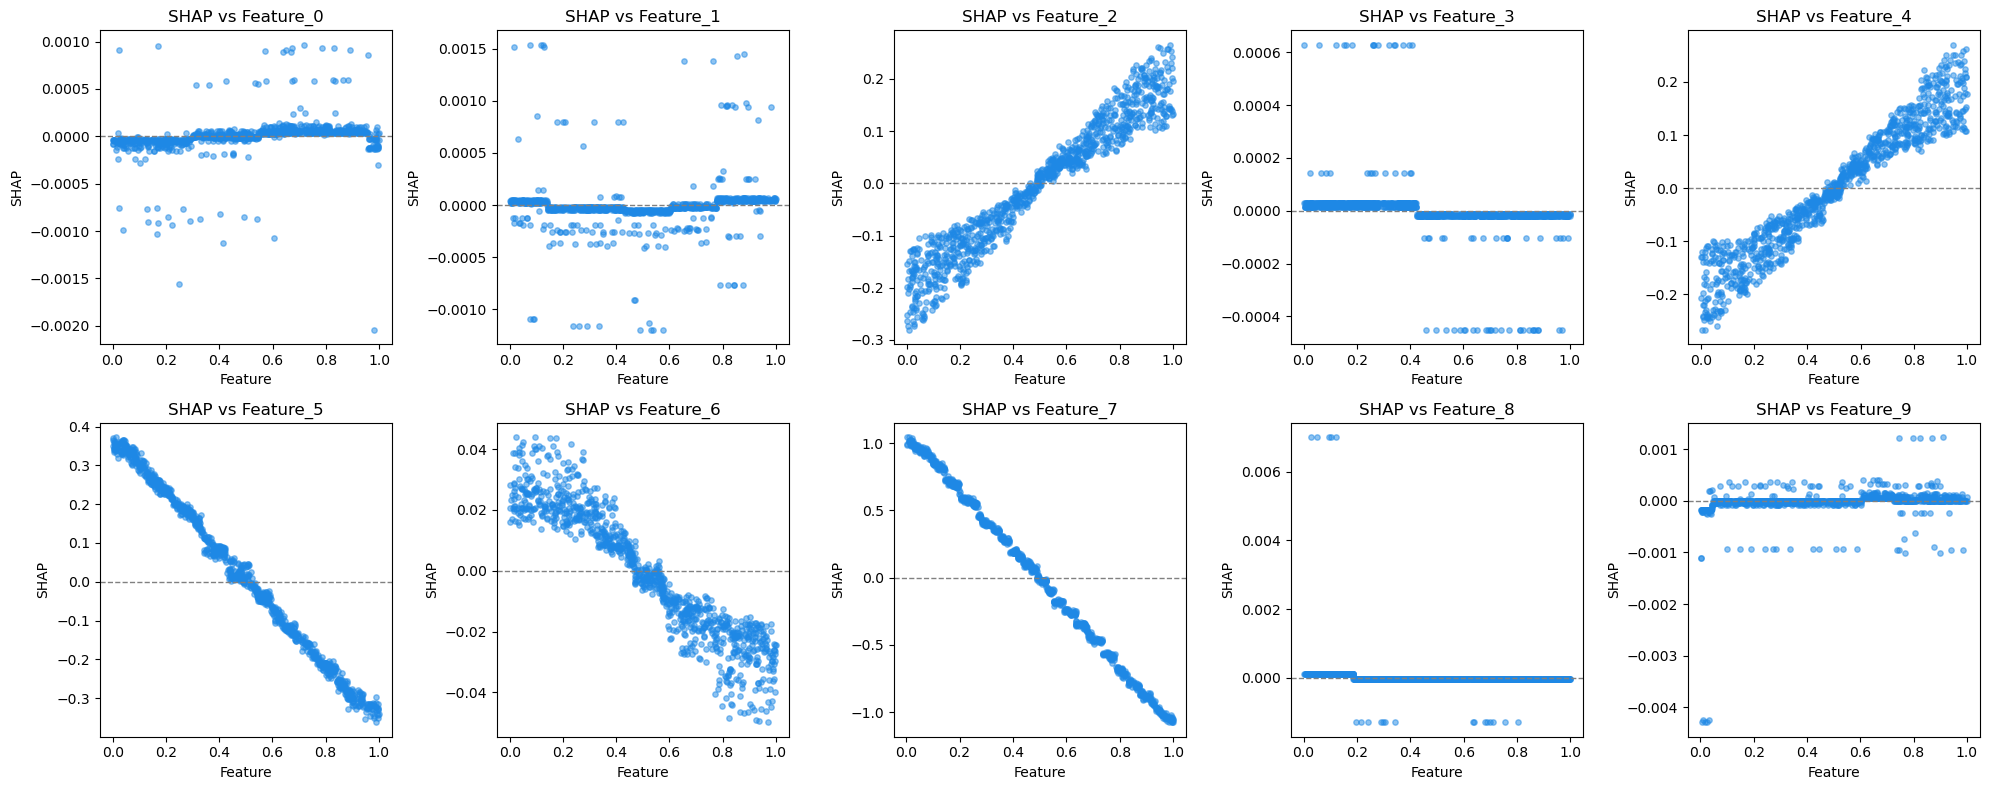

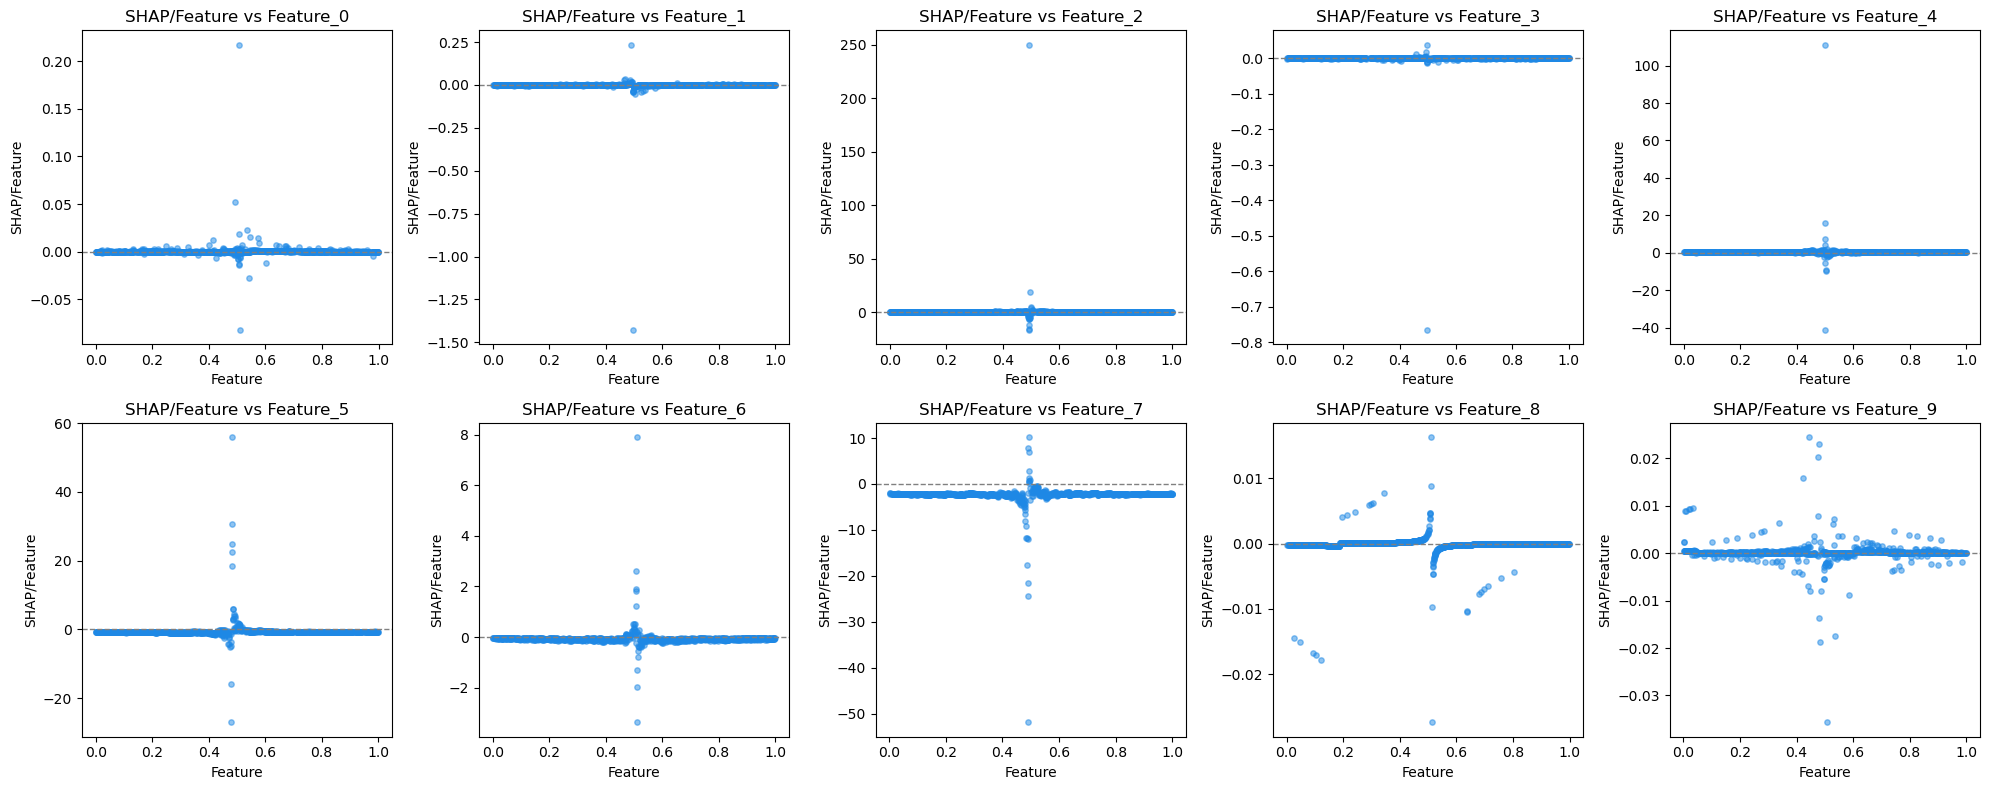

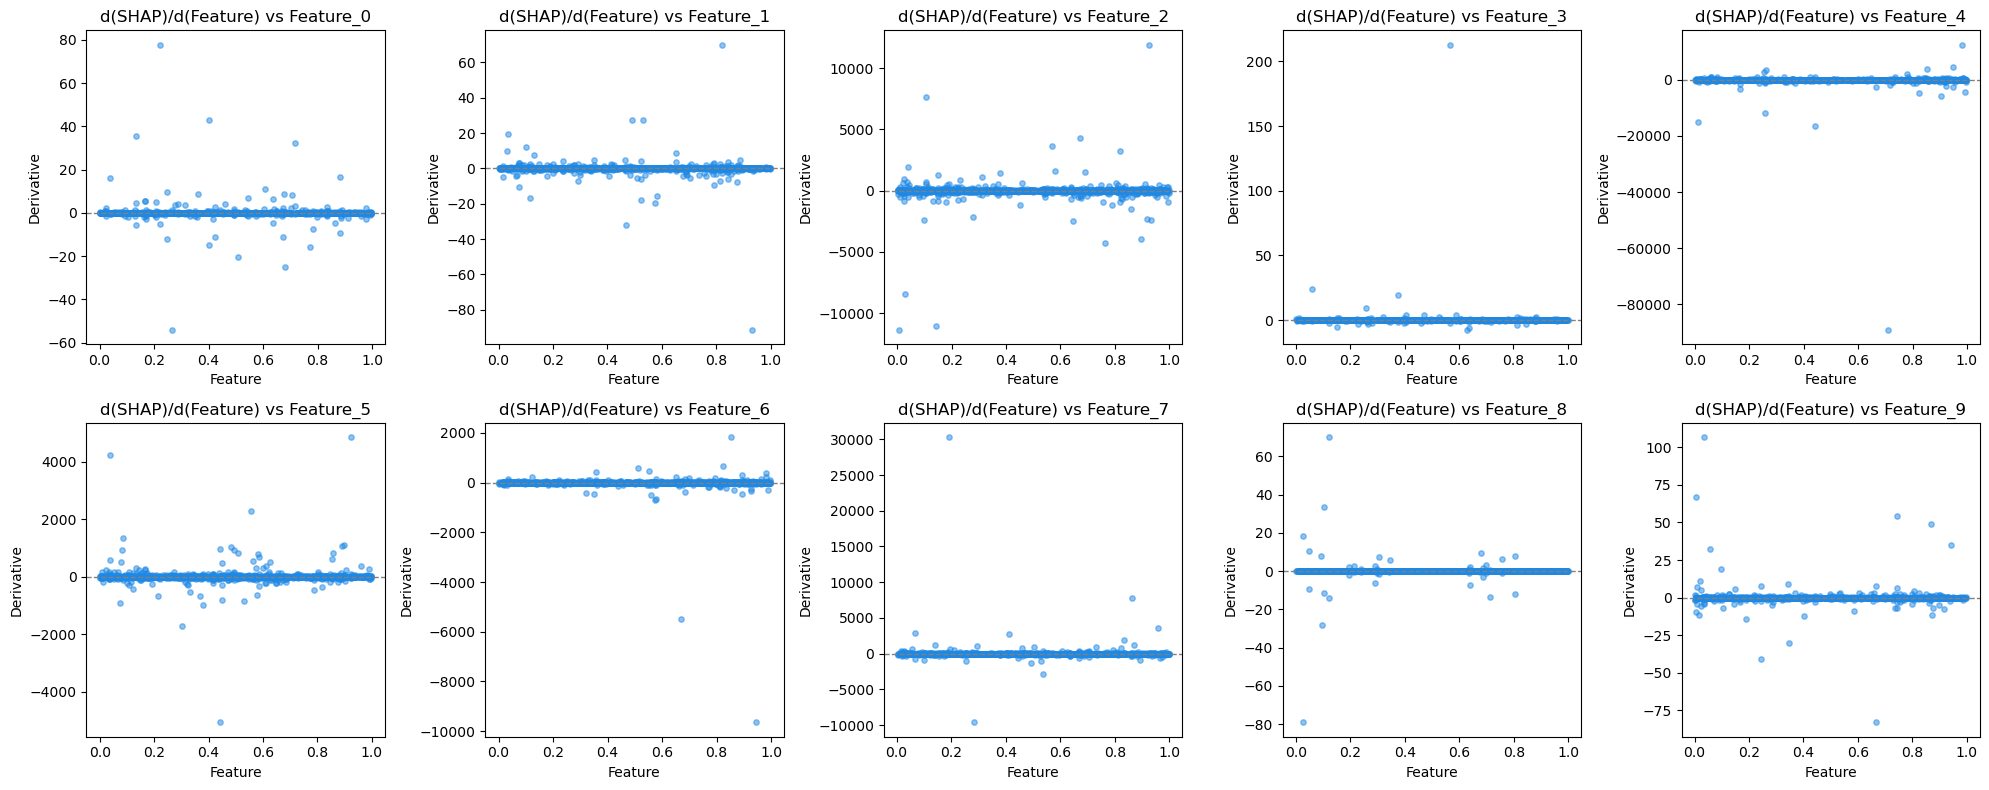

In [15]:

# 6. Visualization (SHAP)
plot_shap_analysis(shap_values, feature_names)


#### try to look for feature interactions
we should see some now


--- Computing SHAP Interaction Values ---


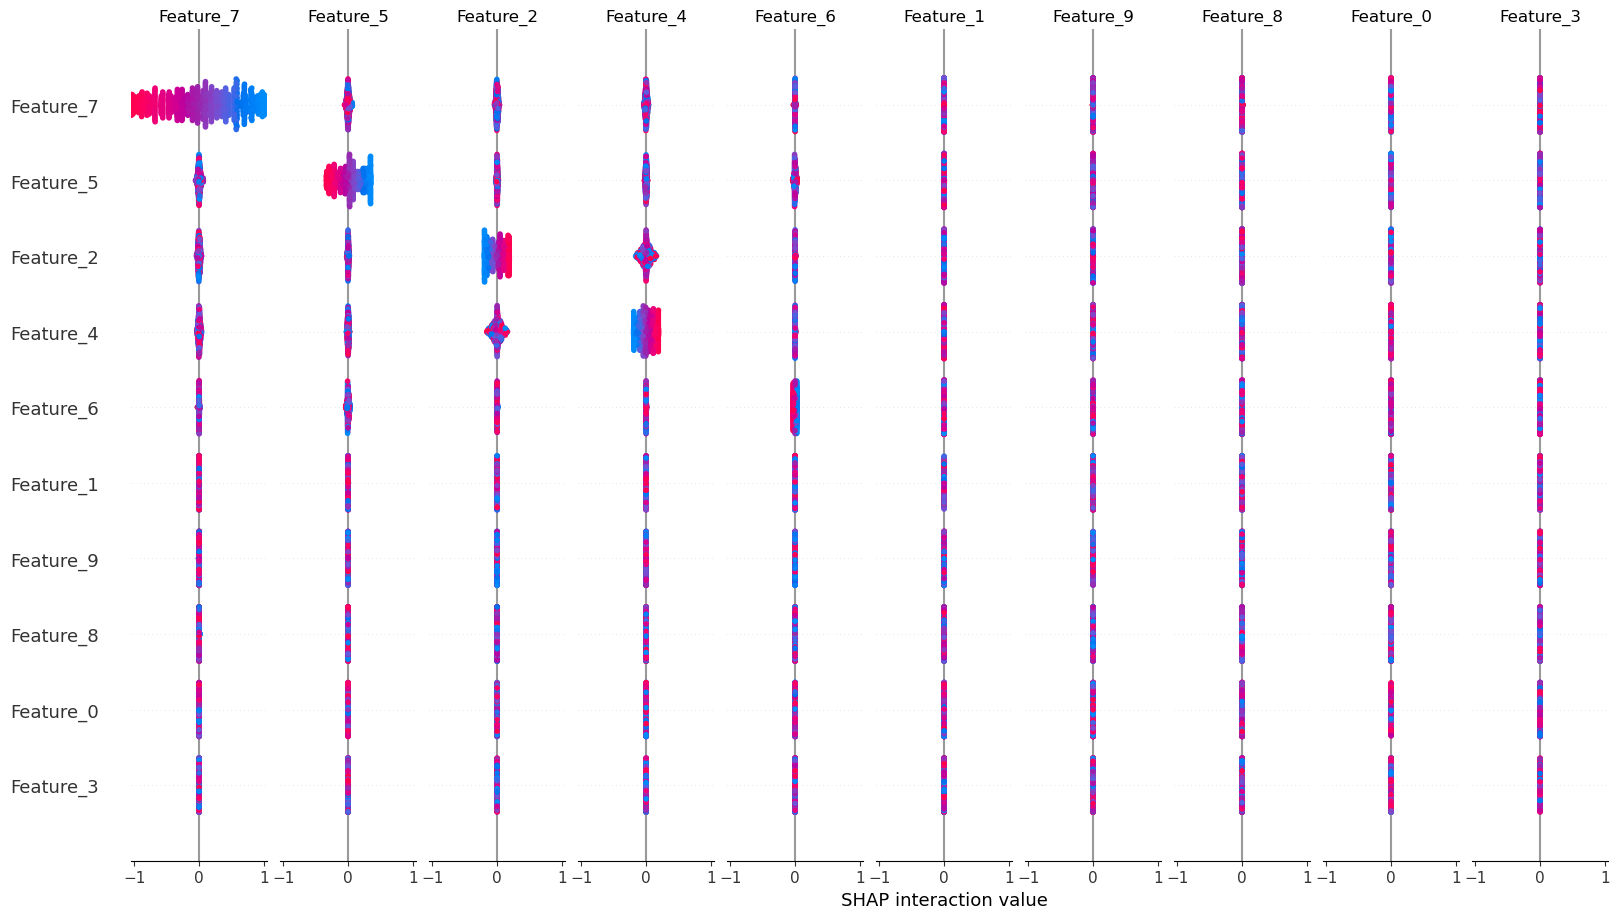


Strongest Interaction found by SHAP: Feature_4 & Feature_2
Plotting pure interaction effect for Feature_4 and Feature_2...


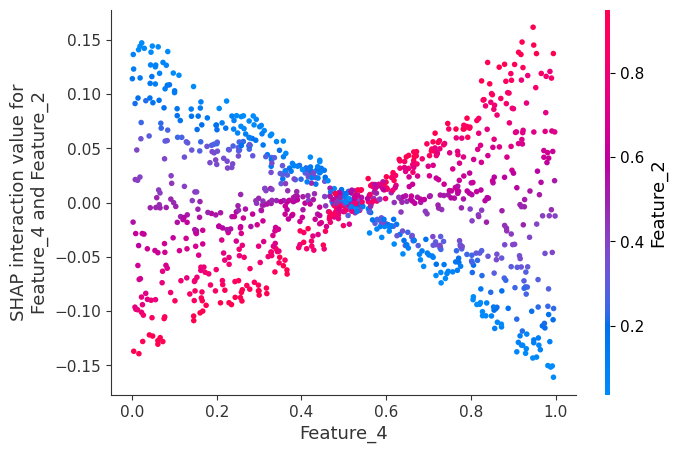

In [16]:

# 7. Deep Dive: SHAP Interaction Analysis
# Note: X_test must be a DataFrame or numpy array. We use X_test directly.
analyze_shap_interactions(model, X_test, feature_names)


#### SHAP summry

In [17]:

# 8. Summary (SHAP)
ranked_features = print_feature_importance(shap_values)



SHAP Global Importance Dictionary:
  Feature_7: 0.5394
  Feature_5: 0.1827
  Feature_2: 0.1086
  Feature_4: 0.1031
  Feature_6: 0.0182
  Feature_1: 0.0001
  Feature_9: 0.0001
  Feature_8: 0.0001
  Feature_0: 0.0001
  Feature_3: 0.0000

Ranked Features (Most to Least Important):
['Feature_7', 'Feature_5', 'Feature_2', 'Feature_4', 'Feature_6', 'Feature_1', 'Feature_9', 'Feature_8', 'Feature_0', 'Feature_3']
